In [1]:
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import TCT

import matplotlib.pyplot as plt
import requests

In [2]:
from TCT.translator_resources import TranslatorResources
resources = TranslatorResources.load()

In [3]:
# Example: Add a custom TRAPI API by fetching its meta_knowledge_graph
# Here we demonstrate with a Pharmacogenomics KP endpoint, registered under a custom name
custom_api_name = "My Pharmacogenomics KP"
custom_query_url = "https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query"
meta_kg_url = "https://multiomics.rtx.ai:9990/PharmacogenomicsKG/meta_knowledge_graph"

response = requests.get(meta_kg_url)
response.raise_for_status()
data = response.json()
for edge in data["edges"]:
    resources.api_names, resources.meta_kg = translator_metakg.add_new_API_for_query(
        resources.api_names, resources.meta_kg, custom_api_name, custom_query_url,
        edge['predicate'], edge['subject'], edge['object'])
resources.rebuild_predicates()
print(f"Added {custom_api_name} with {len(data['edges'])} edges")

Added My Pharmacogenomics KP with 49 edges


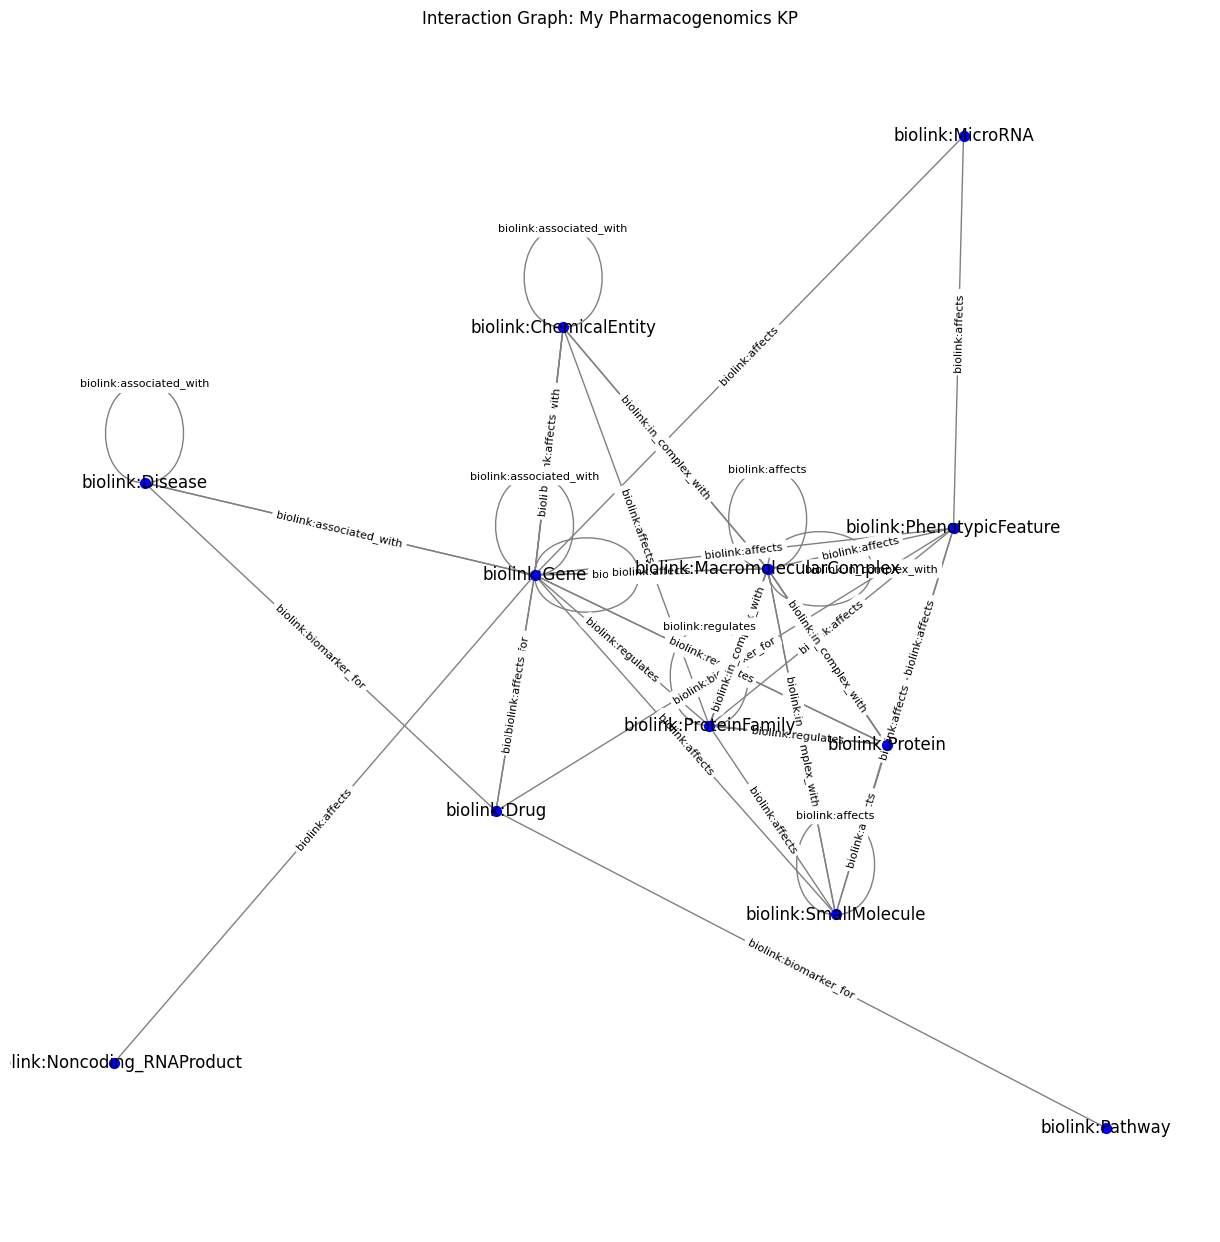

In [4]:
import networkx as nx
selected_KGs = [custom_api_name]

metaKG_sele = resources.meta_kg[resources.meta_kg['API'].isin(selected_KGs)]

# build a multigraph to capture all edges (including duplicates) and their predicates
G = nx.MultiGraph()
for _, row in metaKG_sele.iterrows():
        G.add_edge(row['Subject'], row['Object'], predicate=row['Predicate'])

# layout and draw nodes + edges
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, iterations=20)
nx.draw(G, pos,
                with_labels=True,
                node_size=50,
                font_size=12,
                font_color='black',
                node_color='blue',
                edge_color='gray')

# draw edge labels
edge_labels = nx.get_edge_attributes(G, 'predicate')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title(f'Interaction Graph: {custom_api_name}')
plt.show()

In [5]:
metaKG_sele

,API,Predicate,Subject,Object,URL
23236,My Pharmacogenomics KP,biolink:biomarker_for,biolink:Gene,biolink:Drug,https://multiomics.rtx.ai:9990/Pharmacogenomic...
23237,My Pharmacogenomics KP,biolink:biomarker_for,biolink:Disease,biolink:Drug,https://multiomics.rtx.ai:9990/Pharmacogenomic...
23238,My Pharmacogenomics KP,biolink:biomarker_for,biolink:Pathway,biolink:Drug,https://multiomics.rtx.ai:9990/Pharmacogenomic...
23239,My Pharmacogenomics KP,biolink:biomarker_for,biolink:PhenotypicFeature,biolink:Drug,https://multiomics.rtx.ai:9990/Pharmacogenomic...
23240,My Pharmacogenomics KP,biolink:associated_with,biolink:Gene,biolink:Disease,https://multiomics.rtx.ai:9990/Pharmacogenomic...
23241,My Pharmacogenomics KP,biolink:associated_with,biolink:Gene,biolink:ChemicalEntity,https://multiomics.rtx.ai:9990/Pharmacogenomic...
23242,My Pharmacogenomics KP,biolink:associated_with,biolink:ChemicalEntity,biolink:Gene,https://multiomics.rtx.ai:9990/Pharmacogenomic...
23243,My Pharmacogenomics KP,biolink:associated_with,biolink:ChemicalEntity,biolink:ChemicalEntity,https://multiomics.rtx.ai:9990/Pharmacogenomic...
23244,My Pharmacogenomics KP,biolink:associated_with,biolink:Disease,biolink:Gene,https://multiomics.rtx.ai:9990/Pharmacogenomic...
23245,My Pharmacogenomics KP,biolink:associated_with,biolink:Gene,biolink:Gene,https://multiomics.rtx.ai:9990/Pharmacogenomic...


In [6]:
# select a list of APIs to use and a list of predicates to use
selected_APIlist = [
    custom_api_name,
    'Clinical Trials KP - TRAPI 1.5.0', 
    'Drug Approvals KP - TRAPI 1.5.0',
]

filtered = resources.filter(selected_APIlist) if selected_APIlist else resources
print(filtered.api_names)
print(filtered.meta_kg.shape)

{'My Pharmacogenomics KP': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query'}
(96, 5)


In [7]:
nb_result = TCT.Neiborhood_finder(input_node='MONDO:0018874',  # AML (Acute Myeloid Leukemia)
                                   node2_categories=['biolink:SmallMolecule', 'biolink:Drug', 'biolink:ChemicalEntity'],
                                   resources=filtered)
input_node_id = nb_result.input_node_id
result = nb_result.knowledge_graph
result_parsed = nb_result.parsed
result_ranked_by_primary_infores = nb_result.ranked

MONDO:0018874
Drug Approvals KP - TRAPI 1.5.0: Success!
Clinical Trials KP - TRAPI 1.5.0: Success!


[Text(0.5, 0, 'Voriconazole'), Text(2.5, 0, 'CDK9 Inhibitor PRT2527'), Text(4.5, 0, 'Zarnestra'), Text(6.5, 0, 'daunorubicin hydrochloride'), Text(8.5, 0, 'IADADEMSTAT'), Text(10.5, 0, 'GSK 1120212'), Text(12.5, 0, 'Calcium folinate'), Text(14.5, 0, 'HMA'), Text(16.5, 0, 'Endotoxins'), Text(18.5, 0, 'Cladribine Liquid Injection'), Text(20.5, 0, 'Aprepitant'), Text(22.5, 0, 'venetoclax 100 MG Oral Tablet [Venclexta]'), Text(24.5, 0, 'Inhibitor'), Text(26.5, 0, 'venetoclax Oral Tablet'), Text(28.5, 0, 'Atorvastatin'), Text(30.5, 0, 'Vidaza'), Text(32.5, 0, '5-(N,N-hexamethylene)amiloride'), Text(34.5, 0, 'epacadostat'), Text(36.5, 0, 'ALT-803'), Text(38.5, 0, 'CFI-400945'), Text(40.5, 0, 'evorpacept'), Text(42.5, 0, '8-Chloroadenosine'), Text(44.5, 0, 'dalbavancin'), Text(46.5, 0, 'SGN-CD123A'), Text(48.5, 0, 'scandium atom')]


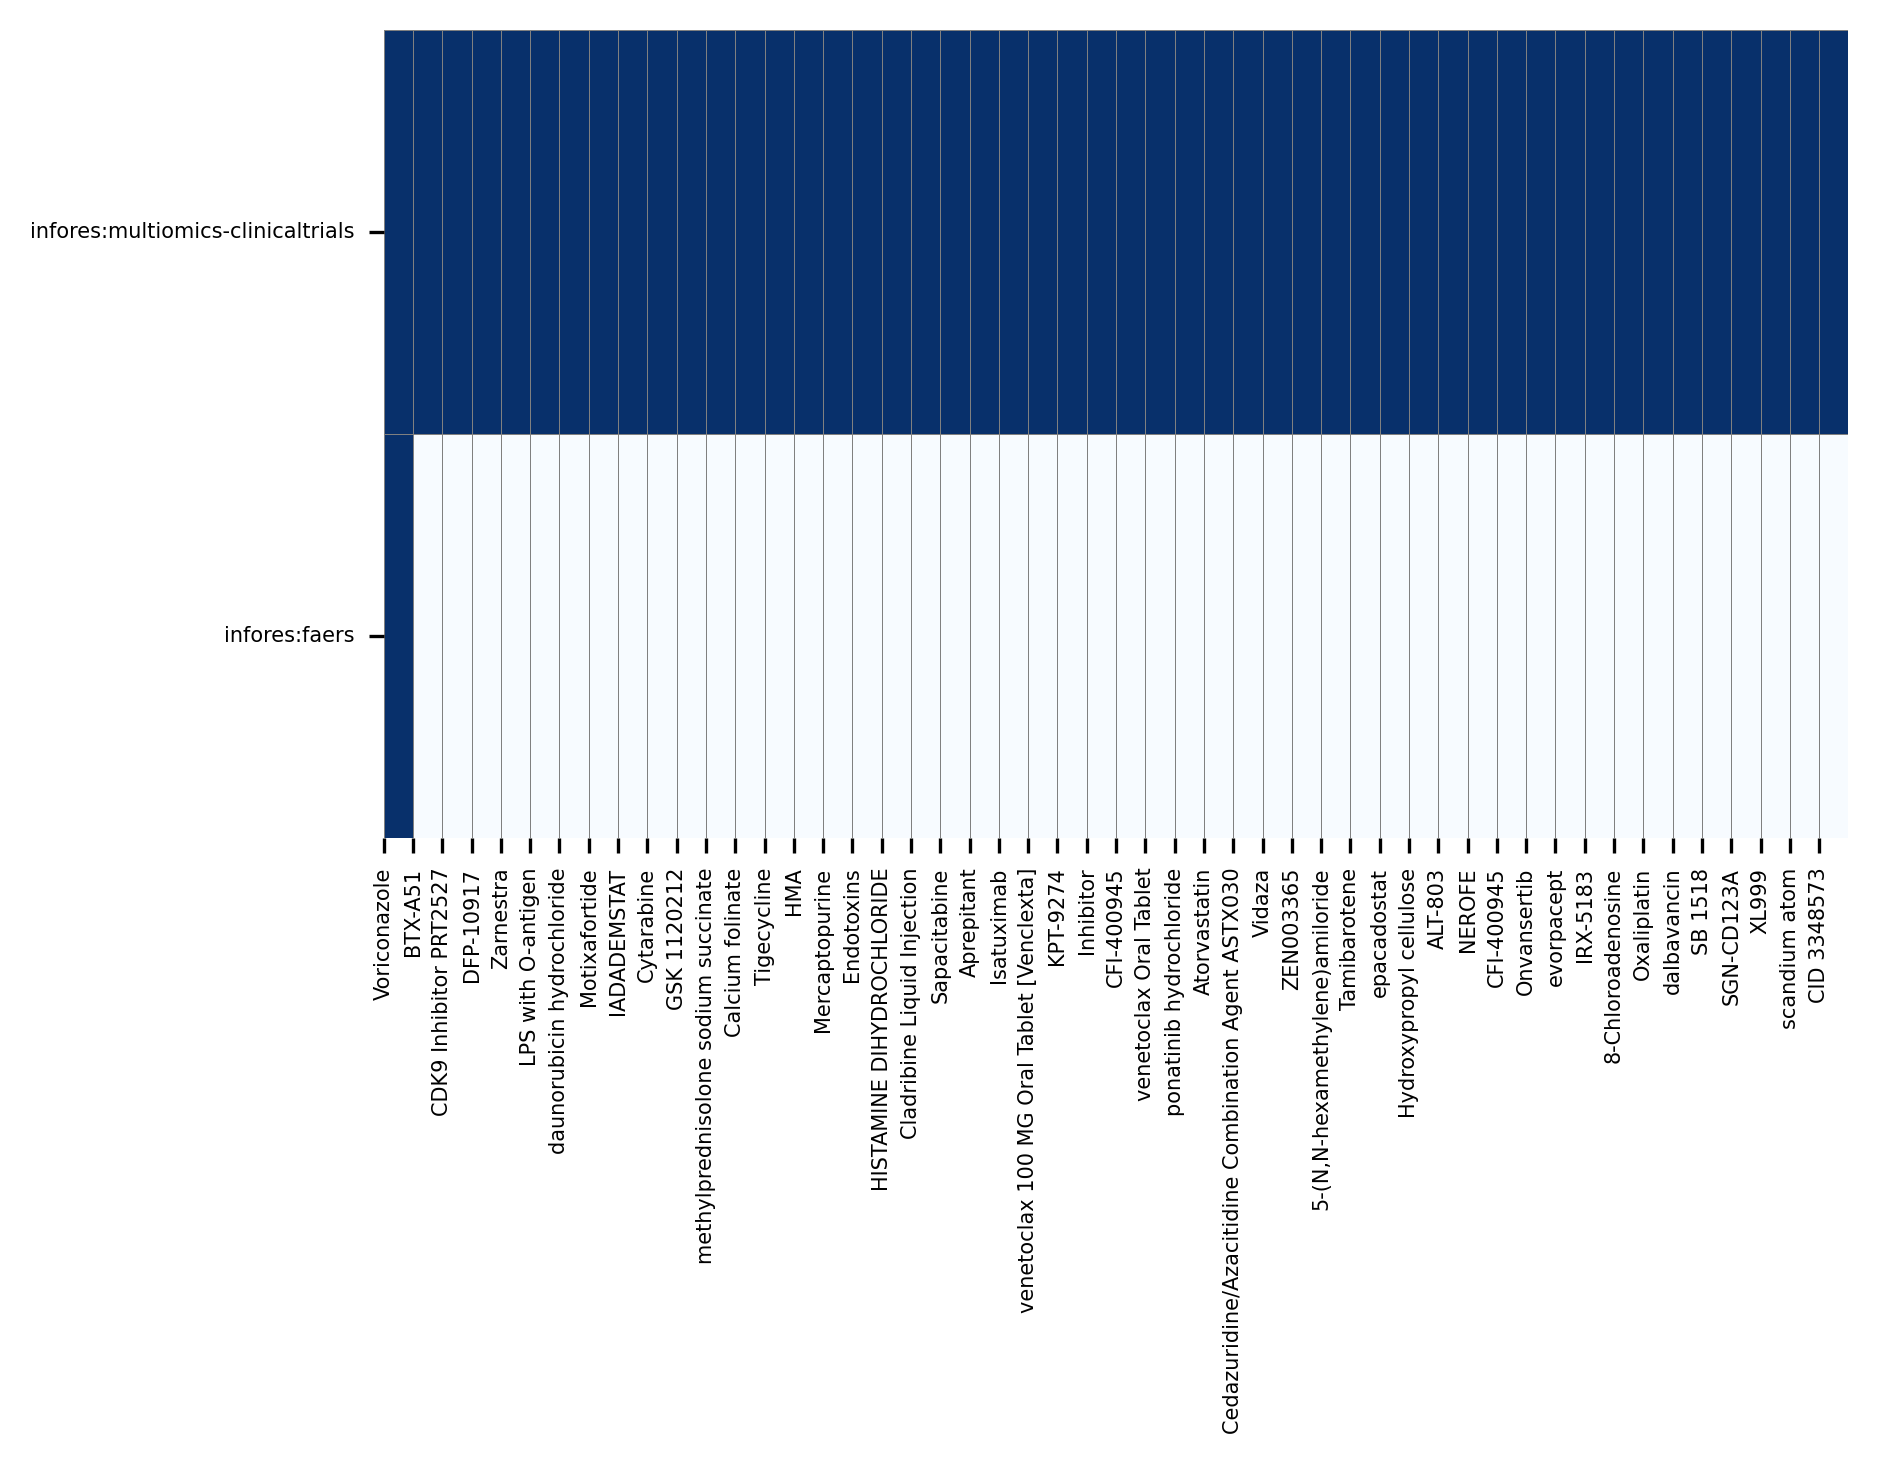

[Text(0.5, 0, 'Voriconazole'), Text(2.5, 0, 'CDK9 Inhibitor PRT2527'), Text(4.5, 0, 'Zarnestra'), Text(6.5, 0, 'daunorubicin hydrochloride'), Text(8.5, 0, 'IADADEMSTAT'), Text(10.5, 0, 'GSK 1120212'), Text(12.5, 0, 'Calcium folinate'), Text(14.5, 0, 'HMA'), Text(16.5, 0, 'Endotoxins'), Text(18.5, 0, 'Cladribine Liquid Injection'), Text(20.5, 0, 'Aprepitant'), Text(22.5, 0, 'venetoclax 100 MG Oral Tablet [Venclexta]'), Text(24.5, 0, 'Inhibitor'), Text(26.5, 0, 'venetoclax Oral Tablet'), Text(28.5, 0, 'Atorvastatin'), Text(30.5, 0, 'Vidaza'), Text(32.5, 0, '5-(N,N-hexamethylene)amiloride'), Text(34.5, 0, 'epacadostat'), Text(36.5, 0, 'ALT-803'), Text(38.5, 0, 'CFI-400945'), Text(40.5, 0, 'evorpacept'), Text(42.5, 0, '8-Chloroadenosine'), Text(44.5, 0, 'dalbavancin'), Text(46.5, 0, 'SGN-CD123A'), Text(48.5, 0, 'scandium atom')]


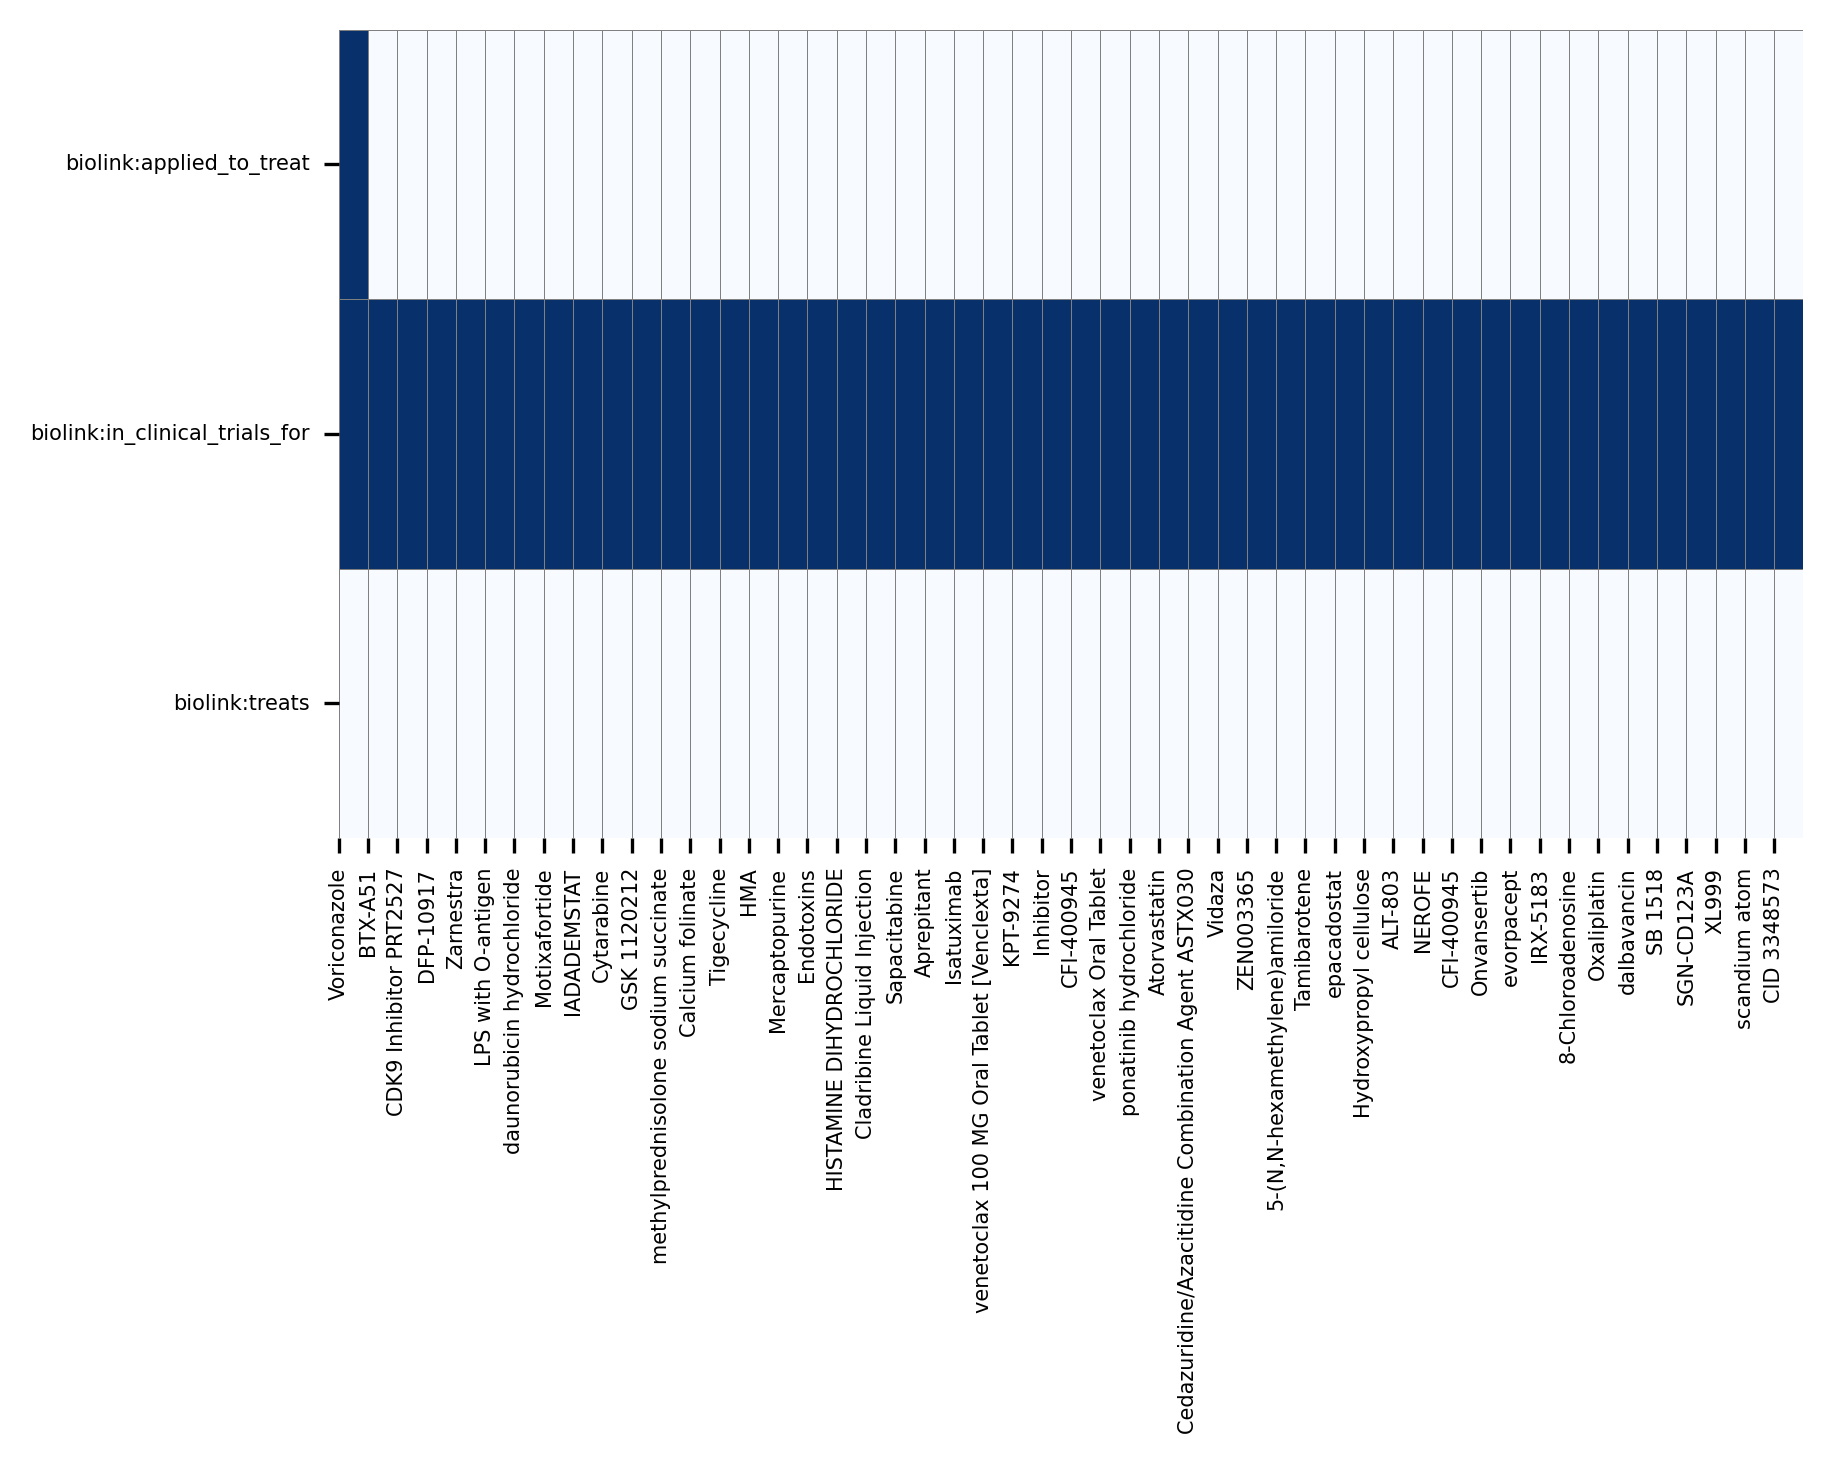

,Voriconazole,BTX-A51,CDK9 Inhibitor PRT2527,DFP-10917,Zarnestra,LPS with O-antigen,daunorubicin hydrochloride,Motixafortide,IADADEMSTAT,Cytarabine,...,hydrogen donor,E7820,Anti-CD33 GSPT1 Degrader BMS-986497,DS 3201b,Eltanexor,Bcl-2/Bcl-XL Inhibitor LP-118,JNJ-67856633,R428,Aklavine,Lomustine
biolink:applied_to_treat,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:in_clinical_trials_for,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
biolink:treats,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Step 8: Visualize the results
TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores=result_ranked_by_primary_infores,
                                result_parsed=result_parsed,
                                num_of_nodes=50,
                                input_query=input_node_id,
                                fontsize=5)

MONDO:0018874
NCBIGene:7157
Drug Approvals KP - TRAPI 1.5.0: Success!
Automat-hetionet(Trapi v1.5.0): Success!
Automat-ctd(Trapi v1.5.0): Success!
Automat-monarchinitiative(Trapi v1.5.0): Success!
Automat-drug-central(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
Automat-robokop(Trapi v1.5.0): Success!
Clinical Trials KP - TRAPI 1.5.0: Success!
BioThings Explorer (BTE) TRAPI: Success!
Service Provider TRAPI: Success!
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
My Pharmacogenomics KP: Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-pharos(Trapi v1.5.0): Success!
Automat-hetionet(Trapi v1.5.0): Success!
Automat-ctd(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
Automat-robokop(Trapi v1.5.0): Success!
Automat-cam-kp(Trapi v1.5.0): Success!
BioThings Explorer (BTE) TRAPI: Success!
Service Provider TRAPI: Success!
NodeNorm does not know about these identifiers: REACT:R-ALL-9692345,UNII:ET4JC4S66E,UNII:E6349B696W,UNII:475247Q

/Users/nelphick/Documents/Repos/Translator_component_toolkit/TCT/visualization.py:356: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


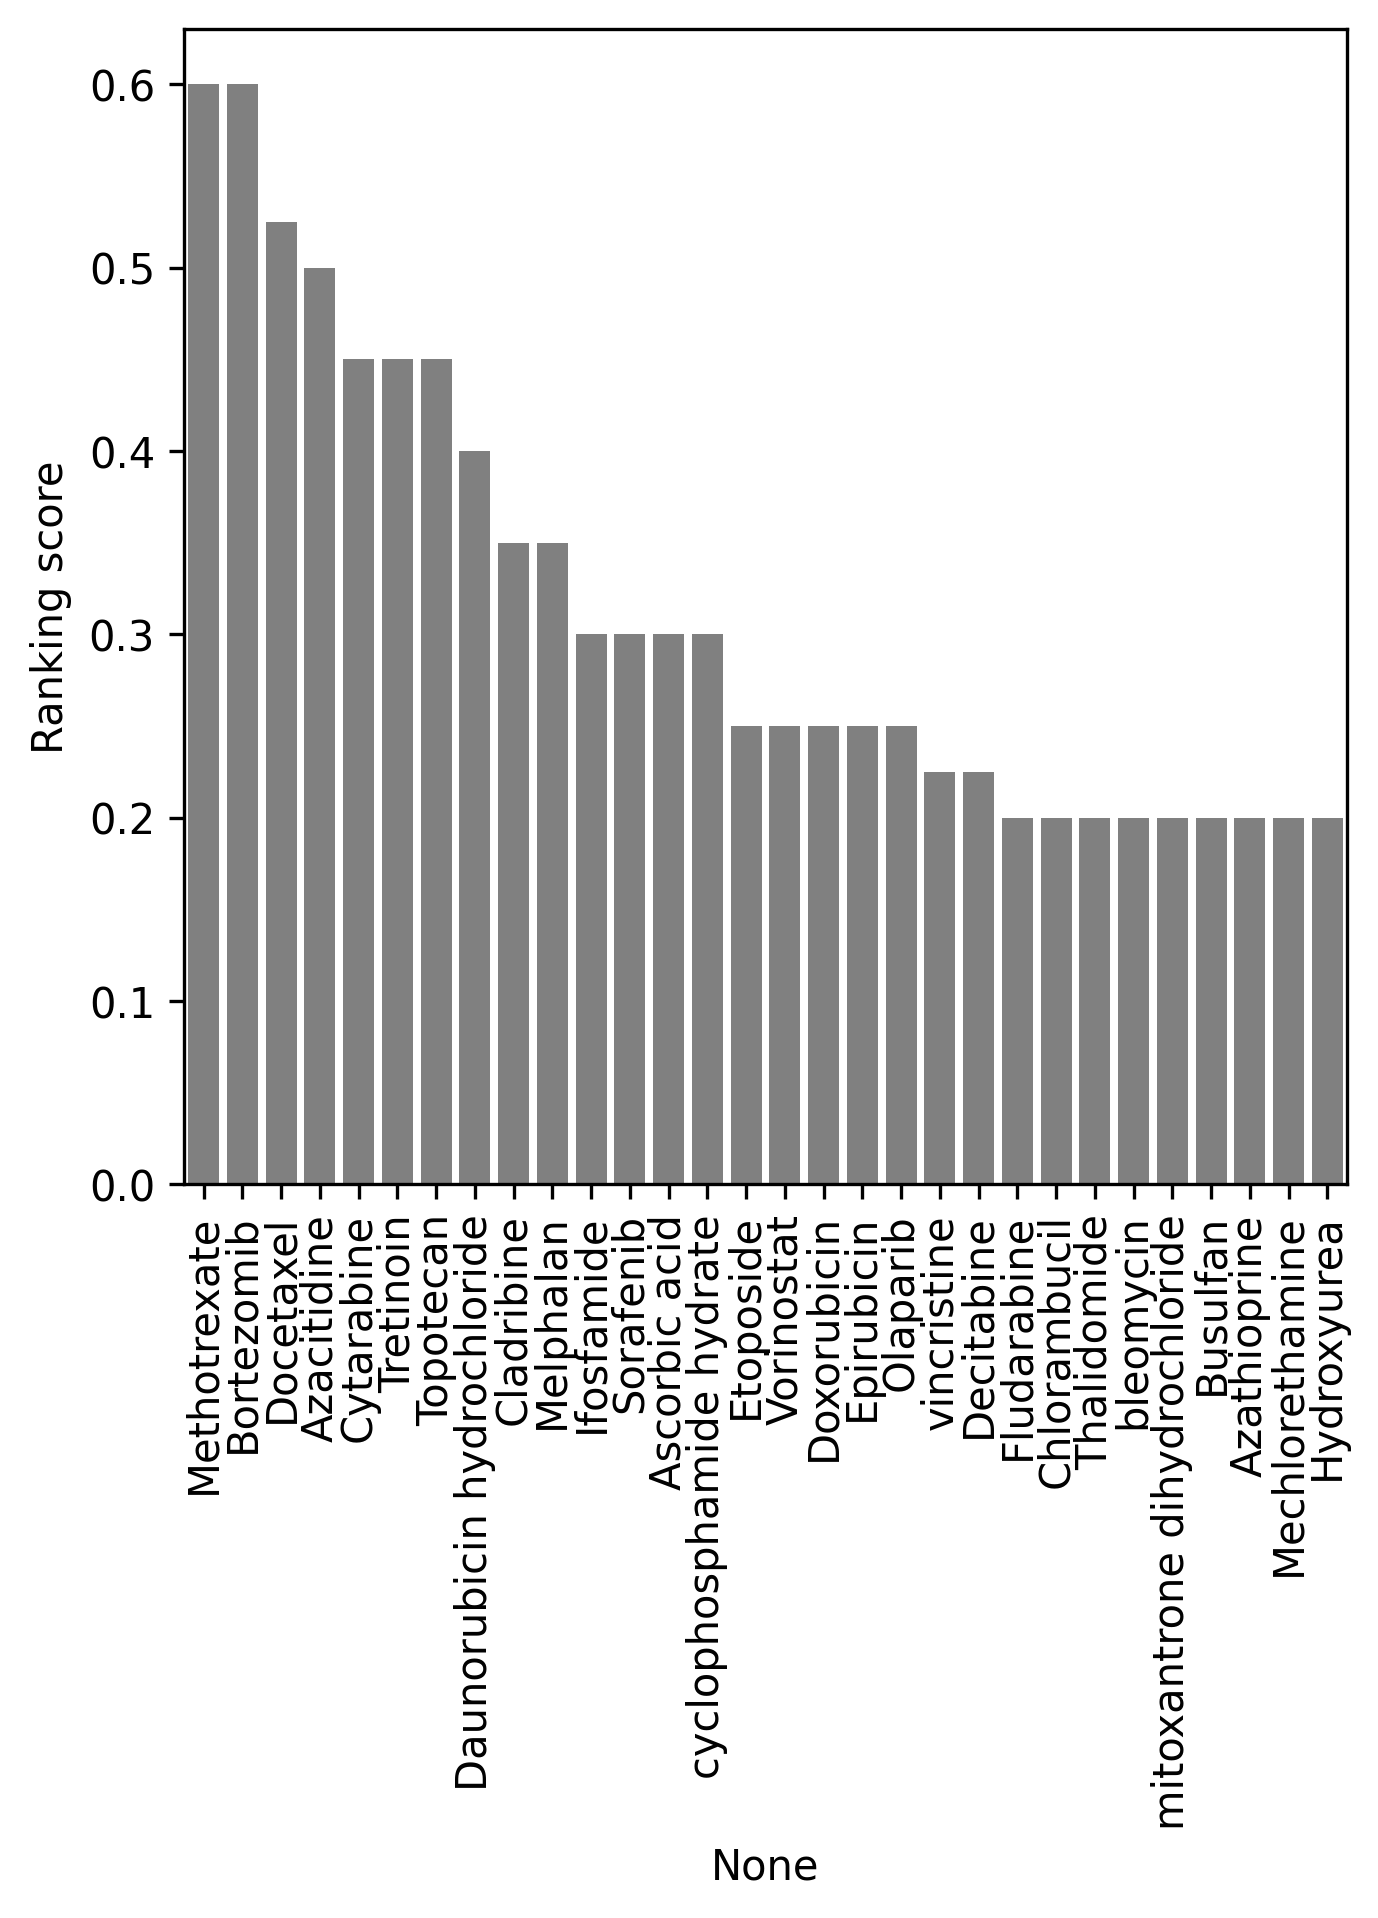

In [9]:
path_result = TCT.Path_finder(input_node1='MONDO:0018874',  # AML
                               input_node2='NCBIGene:7157',  # TP53
                               intermediate_categories=['biolink:Drug', 'biolink:SmallMolecule', 'biolink:ChemicalEntity'],
                               resources=resources)
paths = path_result.paths
input_node1_id = path_result.node1_id
input_node2_id = path_result.node2_id
result1 = path_result.knowledge_graph1
result2 = path_result.knowledge_graph2
result_parsed1 = path_result.parsed1
result_parsed2 = path_result.parsed2
result_ranked_by_primary_infores1 = path_result.ranked1
result_ranked_by_primary_infores2 = path_result.ranked2

In [10]:
paths.head(20)

,score,output_node,predictes1,predictes2,output_node_name
Methotrexate,0.600,CHEBI:44185,biolink:treats_or_applied_or_studied_to_treat;...,biolink:affects; biolink:affects; biolink:affe...,Methotrexate
Bortezomib,0.600,CHEBI:52717,biolink:treats_or_applied_or_studied_to_treat;...,biolink:interacts_with; biolink:affects; bioli...,Bortezomib
Docetaxel,0.525,CHEBI:4672,biolink:treats_or_applied_or_studied_to_treat;...,biolink:affects; biolink:affects; biolink:resp...,Docetaxel
Azacitidine,0.500,CHEBI:2038,biolink:treats_or_applied_or_studied_to_treat;...,biolink:affects; biolink:affects,Azacitidine
Cytarabine,0.450,CHEBI:28680,biolink:treats_or_applied_or_studied_to_treat;...,biolink:affects; biolink:affects; biolink:resp...,Cytarabine
Tretinoin,0.450,CHEBI:15367,biolink:treats_or_applied_or_studied_to_treat;...,biolink:interacts_with; biolink:affects,Tretinoin
Topotecan,0.450,CHEBI:63632,biolink:in_clinical_trials_for; biolink:treats...,biolink:affects; biolink:affects; biolink:affects,Topotecan
Daunorubicin hydrochloride,0.400,CHEBI:31456,biolink:treats_or_applied_or_studied_to_treat;...,biolink:affects; biolink:affects,Daunorubicin hydrochloride
Cladribine,0.350,CHEBI:567361,biolink:treats_or_applied_or_studied_to_treat;...,biolink:affects; biolink:affects,Cladribine
Melphalan,0.350,CHEBI:28876,biolink:in_clinical_trials_for; biolink:treats...,biolink:affects; biolink:affects,Melphalan


In [11]:
forplot = TCT.visulize_path(input_node1_id=input_node1_id,
                            intermediate_node=name_resolver.lookup('Azacitidine').curie,
                            input_node3_id=input_node2_id,
                            result=result1,
                            result2=result2) 

CytoscapeWidget(cytoscape_layout={'name': 'cose', 'title': 'Path', 'nodeSpacing': 80, 'edgeLengthVal': 50}, cy…